<a href="https://colab.research.google.com/github/Omar-RojasGBF/lis5693/blob/main/Final-Project/Project_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

I imported the necessary packages for sentiment analysis.

In [2]:

import requests
import io

url = "https://raw.githubusercontent.com/Omar-RojasGBF/lis5693/refs/heads/main/Final-Project/ufo_sightings.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

df = pd.read_csv(io.StringIO(text))
print(df.head())


          date_time             city_area state country ufo_shape  \
0  10/10/1949 20:30            san marcos    tx      us  cylinder   
1  10/10/1949 21:00          lackland afb    tx     NaN     light   
2  10/10/1955 17:00  chester (uk/england)   NaN      gb    circle   
3  10/10/1956 21:00                  edna    tx      us    circle   
4  10/10/1960 20:00               kaneohe    hi      us     light   

   encounter_length described_encounter_length  \
0            2700.0                 45 minutes   
1            7200.0                    1-2 hrs   
2              20.0                 20 seconds   
3              20.0                   1/2 hour   
4             900.0                 15 minutes   

                                         description date_documented  \
0  This event took place in early fall around 194...       4/27/2004   
1  1949 Lackland AFB&#44 TX.  Lights racing acros...      12/16/2005   
2  Green/Orange circular disc over Chester&#44 En...       1/21/2008

I will be using one of the dataset from the Curated Datasets from textmining-inforpros on GitHub. This "UFO Sightings around the world" dataset was submitted to the Curated Datasets by Georgios Karamanis. I am using the same one but it was uploaded to my Final Project folder on my GitHub repository.

In [3]:
df_subset = df[['date_time', 'description']].copy()

I subsetted 'date_time' and 'description' for the dataset. I performing sentiment analysis on 'description' to examine the emotional tones of the UFO witness reports.

In [4]:
df_subset['description'] = df_subset['description'].str.replace("[^a-zA-Z#]", "   ")

I removed all non-alphabet characters.

In [5]:
df_subset['description'] = df_subset['description'].str.casefold()
print(df_subset.head(10))

          date_time                                        description
0  10/10/1949 20:30  this event took place in early fall around 194...
1  10/10/1949 21:00  1949 lackland afb&#44 tx.  lights racing acros...
2  10/10/1955 17:00  green/orange circular disc over chester&#44 en...
3  10/10/1956 21:00  my older brother and twin sister were leaving ...
4  10/10/1960 20:00  as a marine 1st lt. flying an fj4b fighter/att...
5  10/10/1961 19:00  my father is now 89 my brother 52 the girl wit...
6  10/10/1965 21:00  penarth uk  circle  3mins  stayed 30ft above m...
7  10/10/1965 23:45  a bright orange color changing to reddish colo...
8  10/10/1966 20:00  strobe lighted disk shape object observed clos...
9  10/10/1966 21:00  saucer zaps energy from powerline as my pregna...


All text is converted to lower case.

In [6]:
df1 = pd.DataFrame()
df1['date_time'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

I created a dataframe for staging the output of the polarity_score method of the SentimentIntesityAnalyzer class.

In [9]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = []

# Fill NaN values in 'description' column with an empty string
df_subset['description'] = df_subset['description'].fillna('')

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['description'])
    for key, value in scores.items():
        all_scores_list.append({
            'date_time': row['date_time'],
            'sentiment_type': key,
            'sentiment_score': value
        })

t_df_all_types = pd.DataFrame(all_scores_list)

t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
           date_time sentiment_type  sentiment_score
3   10/10/1949 20:30       compound           0.0000
7   10/10/1949 21:00       compound           0.3612
11  10/10/1955 17:00       compound           0.0000
15  10/10/1956 21:00       compound           0.0000
19  10/10/1960 20:00       compound           0.0000
23  10/10/1961 19:00       compound           0.0000
27  10/10/1965 21:00       compound           0.0000
31  10/10/1965 23:45       compound           0.4404
35  10/10/1966 20:00       compound          -0.4939
39  10/10/1966 21:00       compound           0.2732


I ran a for-loop to iterate the polarity_scores method over each row of input text dataframe 'df_subset'. Another loop is is embedded with the eariler loop to produce the sentiment polarity score for each sentiment type to an intermediate dataframe. Then, the output dataframe is cleaned by deleting the dummy row, removing duplicate rows,  and filtering to only keep rows for sentiment compound type.

In [10]:
df_output = pd.merge(df, t_df_cleaned, on='date_time', how='inner')
print(df_output.head(10))

          date_time             city_area state country ufo_shape  \
0  10/10/1949 20:30            san marcos    tx      us  cylinder   
1  10/10/1949 21:00          lackland afb    tx     NaN     light   
2  10/10/1955 17:00  chester (uk/england)   NaN      gb    circle   
3  10/10/1956 21:00                  edna    tx      us    circle   
4  10/10/1960 20:00               kaneohe    hi      us     light   
5  10/10/1961 19:00               bristol    tn      us    sphere   
6  10/10/1965 21:00    penarth (uk/wales)   NaN      gb    circle   
7  10/10/1965 23:45               norwalk    ct      us      disk   
8  10/10/1966 20:00             pell city    al      us      disk   
9  10/10/1966 21:00              live oak    fl      us      disk   

   encounter_length described_encounter_length  \
0            2700.0                 45 minutes   
1            7200.0                    1-2 hrs   
2              20.0                 20 seconds   
3              20.0                   1/

The 't_df_cleaned' output dataframe is merged with the 'df' input dataframe using the 'date_time' field.

In [11]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,102678.000000
mean,0.087223
std,0.280808
min,-0.913600
25%,0.000000
50%,0.000000
75%,0.340000
max,0.941100


The mean value +0.08 indicates an average neutral to slightly positive sentiment. Mixed emotions, such as awe, confusion, and fear, among the reports could have resulted in this low score. If some of the reports came from pilots or officals with important information, then their confusion could also indicate that the presence of a national security threat. If they were caught off guard by an unexpected military or commercial aircraft, then the UFOs can pose a threat to other flights.

<Axes: title={'center': 'Sentiment Score'}, xlabel='date_documented', ylabel='Mean Sentiment Score'>

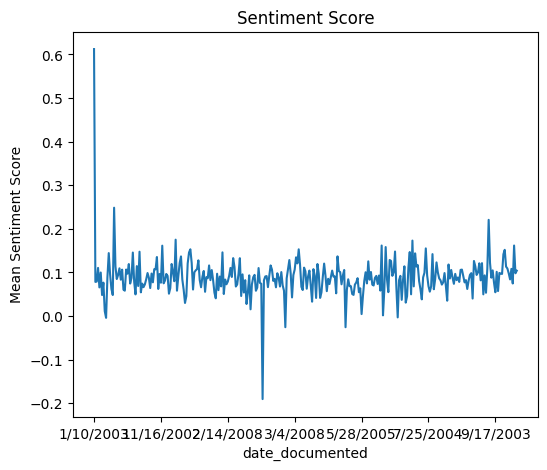

In [12]:
dfg = df_output.groupby(['date_documented'])['sentiment_score'].mean()
dfg.index = dfg.index.astype(str).str.replace(r'\.0$', '', regex=True)

dfg.plot(kind='line', title='Sentiment Score', ylabel='Mean Sentiment Score',
         xlabel='date_documented', figsize=(6, 5))

I attempted to examine how the mean sentiment score changed over time. I used the 'date_documented' field for the x-axis, and the 'Mean Sentiment Score' for the y-axis.

The format of the 'date_documented' records resulted in a tricky timeline to analysis, but there two spikes that appear. January of 2003 seems to have started off with a high positive score, while early 2008 had a spiked decreased for a short duration.

The financial crisis of 2008 could have made people fear that their properties or they themselves would result in high costs for damage from these UFOs.

<Axes: title={'center': 'sentiment_score'}, xlabel='country', ylabel='Mean Sentiment Score'>

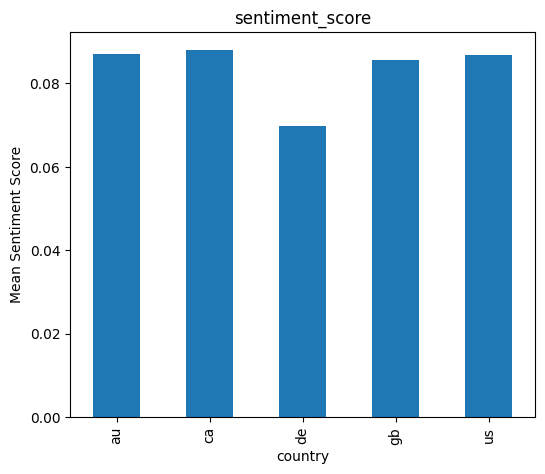

In [13]:
dfg = df_output.groupby(['country'])['sentiment_score'].mean()
dfg.plot(kind='bar', title='sentiment_score', ylabel='Mean Sentiment Score',
         xlabel='country', figsize=(6, 5))

I examined each of the mean sentiment scores from the five countries mentioned in the reports. The country with the least amount of positive sentiment overall is Germany ("de"). The country with the most amount of positive sentiment is Canada ("ca").

Given that Canada borders the United States of America, Canadian residents are probably assuming that the UFOs are US aircraft activities. The region of Europe probably does not have as much aircraft activity as the United States, which then the UFOs in Germany probably rose a lot of suspicion among German residents.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'us'),
  Text(1, 0, 'gb'),
  Text(2, 0, 'ca'),
  Text(3, 0, 'au'),
  Text(4, 0, 'de')])

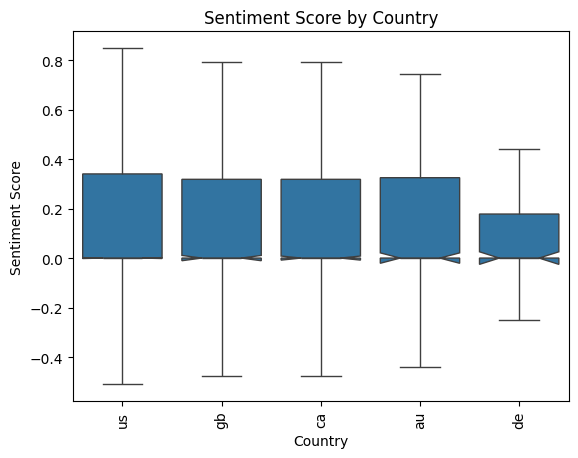

In [14]:
import seaborn as sns

sns.boxplot(x='country', y='sentiment_score', notch = True,
            data=df_output, showfliers=False).set(title='Sentiment Score by Country')

plt.xlabel('Country')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=90)

The box plot confirms that Germany had comparatively the least amount of positive sentiment towards their UFO sightings. However, now the United States to shown to have the most positive sentiment instead of Canada.

This change could still be related to the similar reasoning of US citizens being used to lots of aircraft activity.